In [1]:
import tensorly as tl
import mne
import tensorly as tl
import os

backend = 'numpy'
os.environ['TENSORLY_BACKEND'] = backend
tl.set_backend(backend)
mne.set_log_level('ERROR')

print(mne.get_config_path())
print(mne.get_config('MNE_DATA'))
print(mne.get_config('MOABB_RESULTS'))
print(tl.get_backend())

/user/leuven/352/vsc35289/.mne/mne-python.json
/scratch/leuven/352/vsc35289/mne_data
/data/leuven/352/vsc35289/moabb_results
numpy


In [2]:
from moabb.paradigms import LeftRightImagery
from moabb.datasets import *

sfreq=250
paradigm = LeftRightImagery(resample=sfreq)
datasets = [
    BNCI2014_004()
]


In [ ]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter, ledoit_wolf_shrinkage
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel

bttda = GreedyBTTDA(
    max_blocks=10,
    truncate=False,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=False,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,
    cv=StratifiedKFold(random_state=42, shuffle=True),
    n_jobs=8,
    select=True
)

In [4]:
import tensorly as tl
import pandas as pd
from hoda.tensorize import stf_tensor

select_infos = []
train_infos = []
for dataset in datasets:
    for subject in dataset.subject_list:
        epochs, labels, meta = paradigm.get_data(
            dataset=dataset, 
             subjects=[subject],
             return_epochs=True
        )
        for session in meta['session'].unique():
            idc = meta['session'] == session
            epochs_ses = epochs[idc]
            labels_ses = labels[idc]
            meta_ses = meta[idc]

            X = epochs_ses.get_data()
            X = stf_tensor(X, sfreq=epochs.info['sfreq'], zscore=True)
            y = labels_ses

            print(f'dataset={dataset.code} subject={subject} session={session}')
            bttda.fit(X,y, test=False)
            subj_select_info = pd.DataFrame(bttda.model_select_info_) 
            subj_select_info['dataset'] = dataset.code
            subj_select_info['subject'] = subject
            subj_select_info['session'] = session
            subj_train_info = pd.DataFrame(bttda.train_info_)
            subj_train_info['dataset'] = dataset.code
            subj_train_info['subject'] = subject
            subj_train_info['session'] = session
            select_infos.append(subj_select_info.reset_index())
            train_infos.append(subj_train_info.reset_index())
            # save
            select_info = pd.concat(select_infos, ignore_index=True)
            train_info = pd.concat(train_infos, ignore_index=True)
            select_info.to_csv('block_mi_select.csv')
            train_info.to_csv('block_mi_train.csv')


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  160 events (all good), 3 – 7.5 s, baseline off, ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epo

dataset=BNCI2014-004 subject=1 session=0train
Model selection block 1/10...
rank=(2, 2, 2)
Model selection block 2/10...
rank=(2, 2, 2)
Model selection block 3/10...
rank=(3, 16, 72)
Model selection block 4/10...
rank=(1, 1, 1)
Model selection block 5/10...
rank=(1, 1, 1)
Model selection block 6/10...
rank=(1, 1, 1)
Model selection block 7/10...
rank=(1, 1, 1)
Model selection block 8/10...
rank=(1, 1, 1)
Model selection block 9/10...
rank=(1, 1, 1)
Model selection block 10/10...
rank=(1, 1, 1)
Selected model with ranks [(2, 2, 2), (2, 2, 2), (3, 16, 72), (1, 1, 1), (1, 1, 1), (1, 1, 1), (1, 1, 1), (1, 1, 1), (1, 1, 1), (1, 1, 1)]
Fitting block 1/10...
Fitting block 2/10...
Fitting block 3/10...
Fitting block 4/10...
Fitting block 5/10...
Fitting block 6/10...
Fitting block 7/10...
Fitting block 8/10...
Fitting block 9/10...
Fitting block 10/10...
dataset=BNCI2014-004 subject=1 session=1train
Model selection block 1/10...
rank=(3, 4, 4)
Model selection block 2/10...
rank=(1, 1, 1)
Model

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  160 events (all good), 3 – 7.5 s, baseline off, ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epo

dataset=BNCI2014-004 subject=2 session=0train
Model selection block 1/10...
rank=(1, 1, 1)
Model selection block 2/10...
rank=(2, 2, 2)
Model selection block 3/10...
rank=(2, 2, 2)
Model selection block 4/10...
rank=(3, 4, 4)
Model selection block 5/10...
rank=(2, 2, 2)
Model selection block 6/10...
rank=(2, 2, 2)
Model selection block 7/10...
rank=(3, 4, 4)
Model selection block 8/10...
rank=(3, 4, 4)
Model selection block 9/10...
rank=(3, 4, 4)
Model selection block 10/10...
rank=(3, 4, 4)
Selected model with ranks [(1, 1, 1), (2, 2, 2), (2, 2, 2), (3, 4, 4), (2, 2, 2), (2, 2, 2), (3, 4, 4), (3, 4, 4), (3, 4, 4), (3, 4, 4)]
Fitting block 1/10...
Fitting block 2/10...
Fitting block 3/10...
Fitting block 4/10...
Fitting block 5/10...
Fitting block 6/10...
Fitting block 7/10...
Fitting block 8/10...
Fitting block 9/10...
Fitting block 10/10...
dataset=BNCI2014-004 subject=2 session=1train
Model selection block 1/10...
rank=(3, 8, 8)
Model selection block 2/10...
rank=(1, 1, 1)
Model sel

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  160 events (all good), 3 – 7.5 s, baseline off, ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epo

...

dataset=BNCI2014-004 subject=7 session=0train
Model selection block 1/10...
rank=(1, 1, 1)
Model selection block 2/10...
rank=(3, 16, 64)
Model selection block 3/10...
rank=(3, 4, 4)
Model selection block 4/10...
rank=(1, 1, 1)
Model selection block 5/10...
rank=(2, 2, 2)
Model selection block 6/10...
rank=(2, 2, 2)
Model selection block 7/10...
rank=(3, 4, 4)
Model selection block 8/10...
rank=(2, 2, 2)
Model selection block 9/10...
rank=(2, 2, 2)
Model selection block 10/10...
rank=(3, 4, 4)
Selected model with ranks [(1, 1, 1), (3, 16, 64), (3, 4, 4), (1, 1, 1), (2, 2, 2), (2, 2, 2), (3, 4, 4), (2, 2, 2), (2, 2, 2), (3, 4, 4)]
Fitting block 1/10...
Fitting block 2/10...
Fitting block 3/10...
Fitting block 4/10...
Fitting block 5/10...
Fitting block 6/10...
Fitting block 7/10...
Fitting block 8/10...
Fitting block 9/10...
Fitting block 10/10...
dataset=BNCI2014-004 subject=7 session=1train
Model selection block 1/10...
rank=(3, 16, 72)
Model selection block 2/10...
rank=(1, 1, 1)
Mod

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  160 events (all good), 3 – 7.5 s, baseline off, ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  160 events (all good), 3 – 7.5 s, baseline off, ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epo

dataset=BNCI2014-004 subject=8 session=0train
Model selection block 1/10...
rank=(3, 8, 8)
Model selection block 2/10...
rank=(3, 4, 4)
Model selection block 3/10...
rank=(3, 4, 4)
Model selection block 4/10...
rank=(2, 2, 2)
Model selection block 5/10...
rank=(3, 4, 4)
Model selection block 6/10...
rank=(3, 8, 8)
Model selection block 7/10...
rank=(1, 1, 1)
Model selection block 8/10...
rank=(3, 8, 8)
Model selection block 9/10...
rank=(3, 4, 4)
Model selection block 10/10...
rank=(1, 1, 1)
Selected model with ranks [(3, 8, 8), (3, 4, 4), (3, 4, 4), (2, 2, 2), (3, 4, 4), (3, 8, 8), (1, 1, 1), (3, 8, 8), (3, 4, 4), (1, 1, 1)]
Fitting block 1/10...
Fitting block 2/10...
Fitting block 3/10...
Fitting block 4/10...
Fitting block 5/10...
Fitting block 6/10...
Fitting block 7/10...
Fitting block 8/10...
Fitting block 9/10...
Fitting block 10/10...
dataset=BNCI2014-004 subject=8 session=1train
Model selection block 1/10...
rank=(1, 1, 1)
Model selection block 2/10...
rank=(3, 16, 64)
Model s

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  160 events (all good), 3 – 7.5 s, baseline off, ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epo

dataset=BNCI2014-004 subject=9 session=0train
Model selection block 1/10...
rank=(1, 1, 1)
Model selection block 2/10...
rank=(2, 2, 2)
Model selection block 3/10...
rank=(3, 4, 4)
Model selection block 4/10...
rank=(3, 4, 4)
Model selection block 5/10...
rank=(2, 2, 2)
Model selection block 6/10...
rank=(2, 2, 2)
Model selection block 7/10...
rank=(3, 16, 16)
Model selection block 8/10...
rank=(3, 8, 8)
Model selection block 9/10...
rank=(2, 2, 2)
Model selection block 10/10...
rank=(3, 4, 4)
Selected model with ranks [(1, 1, 1), (2, 2, 2), (3, 4, 4), (3, 4, 4), (2, 2, 2), (2, 2, 2), (3, 16, 16), (3, 8, 8), (2, 2, 2), (3, 4, 4)]
Fitting block 1/10...
Fitting block 2/10...
Fitting block 3/10...
Fitting block 4/10...
Fitting block 5/10...
Fitting block 6/10...
Fitting block 7/10...
Fitting block 8/10...
Fitting block 9/10...
Fitting block 10/10...
dataset=BNCI2014-004 subject=9 session=1train
Model selection block 1/10...
rank=(2, 2, 2)
Model selection block 2/10...
rank=(2, 2, 2)
Model

In [5]:
select_info

,block,rank,fold,n_features_orig,n_features,hoda,train_score,val_score,dataset,subject,session
0,0,"(1, 1, 1)",0,1,1,"HODA(init='random', max_iter=128, obj='tr', ra...",0.999566,0.930556,BNCI2014-004,1,0train
1,0,"(2, 2, 2)",0,8,3,"HODA(init='random', max_iter=128, obj='tr', ra...",0.995660,0.930556,BNCI2014-004,1,0train
2,0,"(3, 4, 4)",0,48,7,"HODA(init='random', max_iter=128, obj='tr', ra...",0.984809,0.902778,BNCI2014-004,1,0train
3,0,"(3, 8, 8)",0,192,27,"HODA(init='random', max_iter=128, obj='tr', ra...",0.991319,0.861111,BNCI2014-004,1,0train
4,0,"(3, 16, 16)",0,768,100,"HODA(init='random', max_iter=128, obj='tr', ra...",1.000000,0.847222,BNCI2014-004,1,0train
...,...,...,...,...,...,...,...,...,...,...,...
17995,9,"(3, 8, 8)",4,3908,307,"HODA(init='random', max_iter=128, obj='tr', ra...",1.000000,0.773438,BNCI2014-004,9,4test
17996,9,"(3, 16, 16)",4,4484,392,"HODA(init='random', max_iter=128, obj='tr', ra...",1.000000,0.769531,BNCI2014-004,9,4test
17997,9,"(3, 16, 32)",4,5252,412,"HODA(init='random', max_iter=128, obj='tr', ra...",1.000000,0.769531,BNCI2014-004,9,4test
17998,9,"(3, 16, 64)",4,6788,450,"HODA(init='random', max_iter=128, obj='tr', ra...",1.000000,0.769531,BNCI2014-004,9,4test


In [6]:
select_info

,block,rank,fold,n_features_orig,n_features,hoda,train_score,val_score,dataset,subject,session
0,0,"(1, 1, 1)",0,1,1,"HODA(init='random', max_iter=128, obj='tr', ra...",0.999566,0.930556,BNCI2014-004,1,0train
1,0,"(2, 2, 2)",0,8,3,"HODA(init='random', max_iter=128, obj='tr', ra...",0.995660,0.930556,BNCI2014-004,1,0train
2,0,"(3, 4, 4)",0,48,7,"HODA(init='random', max_iter=128, obj='tr', ra...",0.984809,0.902778,BNCI2014-004,1,0train
3,0,"(3, 8, 8)",0,192,27,"HODA(init='random', max_iter=128, obj='tr', ra...",0.991319,0.861111,BNCI2014-004,1,0train
4,0,"(3, 16, 16)",0,768,100,"HODA(init='random', max_iter=128, obj='tr', ra...",1.000000,0.847222,BNCI2014-004,1,0train
...,...,...,...,...,...,...,...,...,...,...,...
17995,9,"(3, 8, 8)",4,3908,307,"HODA(init='random', max_iter=128, obj='tr', ra...",1.000000,0.773438,BNCI2014-004,9,4test
17996,9,"(3, 16, 16)",4,4484,392,"HODA(init='random', max_iter=128, obj='tr', ra...",1.000000,0.769531,BNCI2014-004,9,4test
17997,9,"(3, 16, 32)",4,5252,412,"HODA(init='random', max_iter=128, obj='tr', ra...",1.000000,0.769531,BNCI2014-004,9,4test
17998,9,"(3, 16, 64)",4,6788,450,"HODA(init='random', max_iter=128, obj='tr', ra...",1.000000,0.769531,BNCI2014-004,9,4test


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/p

<Axes: xlabel='block', ylabel='value'>

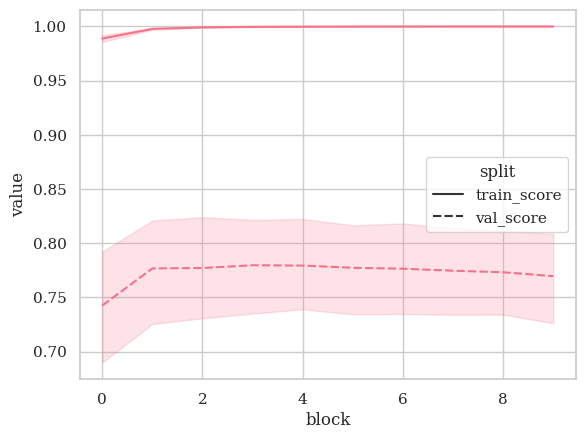

In [10]:
import seaborn as sns

idx = ['dataset', 'subject', 'session', 'block']
df = select_info.groupby(idx)[['train_score', 'val_score']].aggregate('mean')
df = df.melt(var_name='split', ignore_index=False)
df = df.reset_index()
sns.lineplot(data=df, x='block', y='value', style='split')

In [8]:
train_info.to_csv('block_mi_train.csv')
train_info

,index,block,rank,F_tr,F_rt,mse,nmse,dataset,subject,session
0,0,1,"(2, 2, 2)",0.011051,0.035863,9.795474e-01,9.795474e-01,BNCI2014-004,1,0train
1,1,2,"(2, 2, 2)",0.009270,0.052131,9.717783e-01,9.717783e-01,BNCI2014-004,1,0train
2,2,3,"(3, 16, 72)",0.000091,0.615198,3.828406e-30,3.828406e-30,BNCI2014-004,1,0train
3,3,4,"(1, 1, 1)",0.000091,0.615372,3.818944e-30,3.818944e-30,BNCI2014-004,1,0train
4,4,5,"(1, 1, 1)",0.000091,0.615546,3.804186e-30,3.804186e-30,BNCI2014-004,1,0train
...,...,...,...,...,...,...,...,...,...,...
445,5,6,"(1, 1, 1)",0.000053,0.364201,5.978114e-30,5.978114e-30,BNCI2014-004,9,4test
446,6,7,"(3, 8, 8)",0.000053,0.383315,5.851469e-30,5.851469e-30,BNCI2014-004,9,4test
447,7,8,"(2, 2, 2)",0.000053,0.384111,5.821912e-30,5.821912e-30,BNCI2014-004,9,4test
448,8,9,"(1, 1, 1)",0.000053,0.384211,5.816535e-30,5.816535e-30,BNCI2014-004,9,4test


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: xlabel='block', ylabel='nmse'>

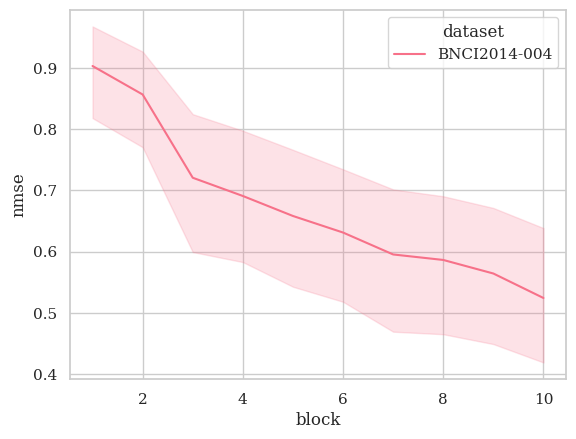

In [9]:
df = train_info.groupby(idx)
df = df['nmse'].aggregate('mean')
df = df.reset_index()
sns.lineplot(data=df, x='block',y='nmse', hue='dataset')